In [1]:
# Importation des librairies utilisées dans le notebook

!pip install optuna
# Masque les FutureWarning de scikit-learn
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Librairies générales
import pandas as pd          # Manipulation de données
import numpy as np           # Calcul numérique
import string                
import re                    # Expressions régulières
import unicodedata           # Normalisation Unicode
#import contractions          # Gestion des contractions
from collections import Counter  
from wordcloud import WordCloud         


from bs4 import BeautifulSoup    

# Librairies d'affichage
import matplotlib.pyplot as plt  
import plotly.graph_objs as go   
import plotly.offline as py      
import plotly.express as px      
import plotly.io as pio          


# Librairies NLTK
import nltk                      
from nltk import sent_tokenize   
from nltk import word_tokenize   
from nltk import pos_tag         
from nltk.stem import WordNetLemmatizer   
from nltk.stem.snowball import SnowballStemmer   
from nltk.corpus import stopwords          


nltk.download("punkt")                      
nltk.download("punkt_tab")                  
nltk.download("averaged_perceptron_tagger") 
nltk.download("averaged_perceptron_tagger_eng")  
nltk.download("tagsets_json")               
nltk.download("tagsets")                    
nltk.download("stopwords")                  
nltk.download("wordnet")                    


import spacy                                
from spacy import displacy                  
from spacy.lang.fr import French            


nlp = spacy.load("en_core_web_sm")          


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report


from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split


import optuna
from sklearn.model_selection import cross_val_score
from sklearn.svm import LinearSVC

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score, hamming_loss, accuracy_score


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 6.5 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package tagsets_json to /root/nltk_data...
[nltk_data]   Unzipping help/tagsets_json.zip.
[nltk_data] Downloading package tagsets to /root/nltk_data...
[nltk_data]   Unzipping help/tagsets.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [2]:
from google.colab import drive
import pandas as pd
import re
import spacy
"""
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Téléchargement des ressources NLTK nécessaires
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
"""

drive.mount('/content/drive')
path = '/content/drive/MyDrive/ColabNotebooks/scitweets_export.tsv'

Mounted at /content/drive


# Clean les Tweets

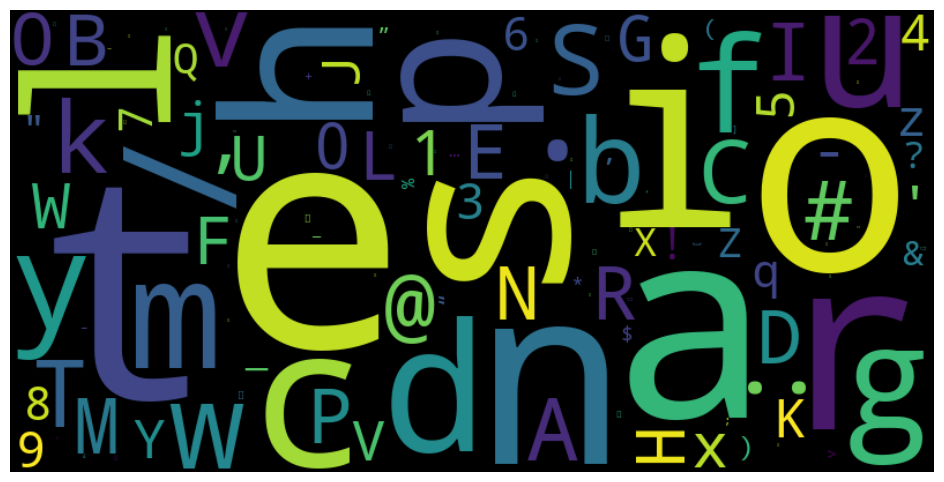

In [3]:
df = pd.read_csv(path, sep='\t')

from collections import Counter

def quick_tokens(series):
    out = []
    for txt in series.dropna():
        out.extend(str(txt).split())
    return out

raw_tokens = quick_tokens(df['text'])
word_counts = Counter(raw_tokens)

wc = WordCloud(width=800, height=400)
wc.generate_from_frequencies(word_counts)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

wc.to_file("wordcloud.png")


Resultat avant le pretraitement

In [4]:
df = pd.read_csv(path, sep='\t')

#traitement des émoticones
emoticons_str = r"""
    (?:
        [:=;] # Eyes
        [oO\-]? # Nose (optional)
        [D\)\]\(\]/\\OpP] # Mouth
    )"""

#Prise en compte des éléments qui doivent être regroupés
regex_str = [
    emoticons_str,
    r'<[^>]+>', # HTML tags
    r'(?:@[\w_]+)', # @-mentions
    r"(?:\#+[\w_]+[\w\'_\-]*[\w_]+)", # hash-tags
    r'http[s]?://(?:[a-z]|[0-9]|[$-_@.&amp;+]|[!*\(\),]|(?:%[0-9a-f][0-9a-f]))+', # URLs

    r'(?:(?:\d+,?)+(?:\.?\d+)?)', # nombres
    r"(?:[a-z][a-z'\-_]+[a-z])", # mots avec - et '
    r'(?:[\w_]+)', # autres mots
    r'(?:\S)' # le reste
]

tokens_re = re.compile(r'('+'|'.join(regex_str)+')', re.VERBOSE | re.IGNORECASE)
emoticon_re = re.compile(r'^'+emoticons_str+'$', re.VERBOSE | re.IGNORECASE)

def tokenize(s):
    return tokens_re.findall(s)

def preprocess(s, lowercase=False):
    tokens = tokenize(s)
    if lowercase:
        tokens = [
            tok if emoticon_re.search(tok) else tok.lower()
            for tok in tokens
        ]
    return tokens


In [5]:
contractions_map = {
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "can't": "cannot", "couldn't": "could not", "won't": "will not",
    "wouldn't": "would not", "shouldn't": "should not", "isn't": "is not",
    "aren't": "are not", "wasn't": "was not", "weren't": "were not",
    "hasn't": "has not", "haven't": "have not", "hadn't": "had not",
    "i'm": "i am", "you're": "you are", "he's": "he is", "she's": "she is",
    "it's": "it is", "we're": "we are", "they're": "they are",
    "i've": "i have", "you've": "you have", "we've": "we have", "they've": "they have",
    "i'll": "i will", "you'll": "you will", "we'll": "we will",
    "they'll": "they will", "let's": "let us", "that's": "that is",
    "what's": "what is", "who's": "who is", "where's": "where is",
    "there's": "there is", "here's": "here is",
}

def expand_contractions(text):
    # Normalisation simple des apostrophes typographiques
    text = text.replace("’", "'")
    tokens = text.split()
    expanded = []
    for t in tokens:
        key = t.lower()
        if key in contractions_map:
            expanded.extend(contractions_map[key].split())
        else:
            expanded.append(t)
    return " ".join(expanded)

NONALPHA_RE = re.compile(r"[^a-zA-Z\s]")

def remove_non_alpha(text):
  text = NONALPHA_RE.sub(" ", text)
  return text


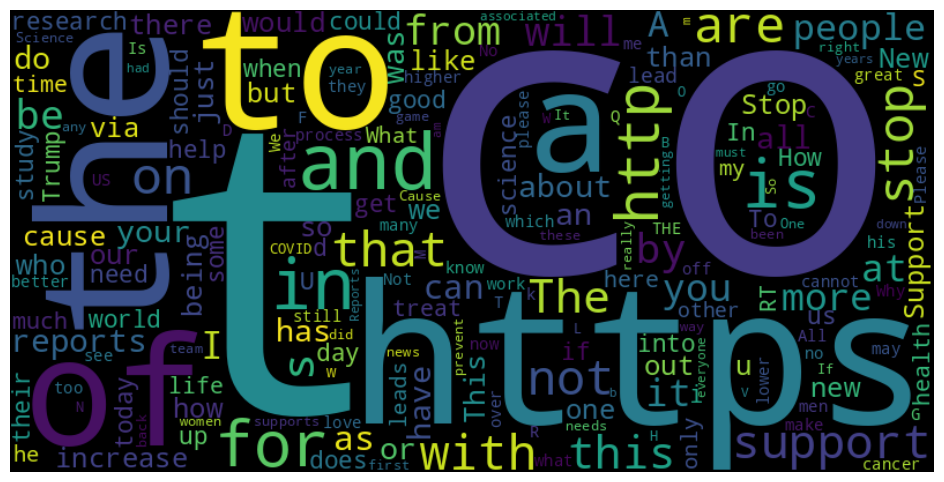

In [6]:
df['text_expanded'] = df['text'].apply(expand_contractions)
df['text_nonalpha'] = df['text_expanded'].apply(remove_non_alpha)
all_words_processed = df['text_nonalpha'].apply(preprocess)
words = [word for sublist in all_words_processed for word in sublist]

word_counts = Counter(words)

wc = WordCloud(width=800, height=400)         # Creation du word cloud
wc.generate_from_frequencies(word_counts)     # Generation

plt.figure(figsize=(12, 6))                   # Affichage
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

wc.to_file("wordcloud2.png")


# Prétraitement ( ne sert plus a rien avec Optuna mais interessant quand meme )

### Sac de mots

In [7]:
from sklearn.feature_extraction.text import CountVectorizer


#Code du cours
vectorizer = CountVectorizer(lowercase=False, stop_words="english", min_df=2, max_df=0.7, ngram_range=(1,1))
X = vectorizer.fit_transform(df["text"])

vocabulaire = vectorizer.get_feature_names_out()
print(vocabulaire[300:310])

print(X.shape)

#lowercase=False: Ne convertit pas en minuscules (respecte la casse).
#stop_words="english": Supprime les mots courants anglais (mots vides).
#min_df=2: Ignore les mots apparaissant dans moins de 2 documents.
#max_df=0.8: Ignore les mots apparaissant dans plus de 80% des documents.
#ngram_range=(1,1): N'extrait que des mots uniques (unigrammes).

METHODE = "SAC DE MOTS"


['Indonesia' 'Industry' 'Instead' 'Institute' 'Interesting'
 'International' 'Iran' 'Is' 'Islam' 'Israel']
(1140, 1905)


##Pondération des mots

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer



#Code du cours
vectorizer = TfidfVectorizer(norm="l2",sublinear_tf=True,min_df=2, max_df=0.8, max_features=5000,ngram_range=(1,2))
X = vectorizer.fit_transform(df["text"])

vocabulaire = vectorizer.get_feature_names_out()
print(vocabulaire[300:310])

print(X.shape)

#norm="l2": Applique une normalisation L2 aux vecteurs TF-IDF.
#sublinear_tf=True: Applique une mise à l'échelle sous-linéaire à la fréquence des termes (1 + log(tf)).
#min_df=2: Ignore les mots apparaissant dans moins de 2 documents.
#max_df=0.8: Ignore les mots apparaissant dans plus de 80% des documents.
#max_features=5000: Limite le vocabulaire aux 5000 termes les plus fréquents.
#ngram_range=(1,2): Extrait des mots seuls (unigrammes) et des paires de mots (bigrammes).

METHODE = "PONDERATION"

['be using' 'be very' 'beaten' 'beaten by' 'beautiful' 'beauty' 'because'
 'because of' 'become' 'becomes']
(1140, 3129)


## Visuel Pretraitement

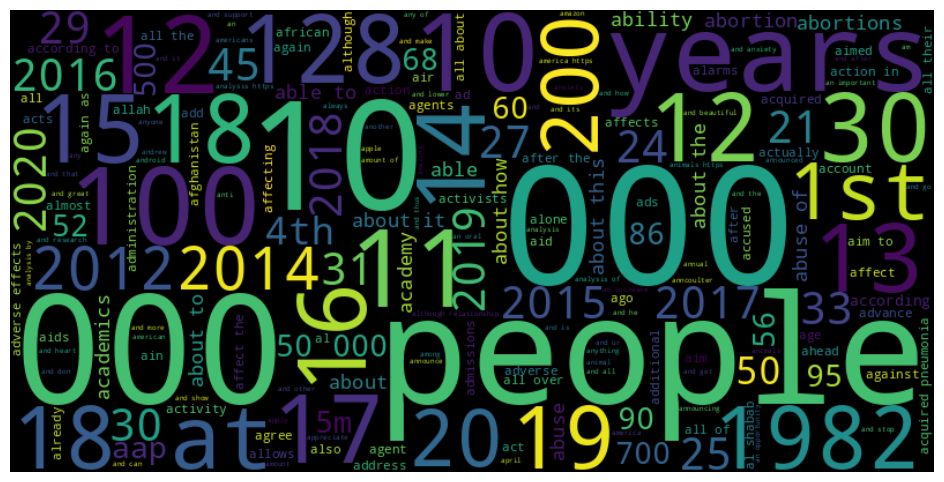

Wordcloud pour la methode : PONDERATION


In [9]:
corpus_tokens = quick_tokens(df['text_nonalpha'])
word_counts_clean = Counter(corpus_tokens)

wc = WordCloud(width=800, height=400)
wc.generate_from_frequencies(word_counts_clean)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

wc.to_file("wordcloud2.png")
print("Wordcloud pour la methode : " + METHODE)


# SCI vs NON-SCI


In [10]:
N_FOLDS = 5

## Classifieur Manuel

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Decision Tree":   DecisionTreeClassifier(random_state=42),
    "Naive Bayes":     MultinomialNB(),
    "SVM":    LinearSVC(random_state=42, max_iter=2000),
    "Random Forest":   RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN":             KNeighborsClassifier(n_neighbors=5),
}


In [12]:
from imblearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate

y = df["science_related"].values

results_baseline = {}

for name, clf in models.items():
    pipe = Pipeline([
        ("sampler", RandomOverSampler(random_state=42)),
        ("clf",     clf),
    ])
    scores = cross_validate(
        pipe, X, y, cv=N_FOLDS,
        scoring=["accuracy", "f1_macro", "precision_macro", "recall_macro"],
        n_jobs=-1
    )
    results_baseline[name] = {
        "accuracy":  scores["test_accuracy"].mean(),
        "f1_macro":  scores["test_f1_macro"].mean(),
        "precision": scores["test_precision_macro"].mean(),
        "recall":    scores["test_recall_macro"].mean(),
    }

df_results = pd.DataFrame(results_baseline).T.sort_values("f1_macro", ascending=False)
print("=== Baseline en CV 3-folds (comparable a Optuna) ===")
print(df_results.round(3).to_string())

best_name = df_results.index[0]
print(f"\nMeilleur modele : {best_name} (F1-macro CV = {df_results.loc[best_name, 'f1_macro']:.3f})")

=== Baseline en CV 3-folds (comparable a Optuna) ===
               accuracy  f1_macro  precision  recall
Naive Bayes       0.809     0.786      0.785   0.791
SVM               0.809     0.770      0.795   0.760
Random Forest     0.776     0.718      0.772   0.717
Decision Tree     0.732     0.705      0.703   0.714
KNN               0.693     0.678      0.685   0.704

Meilleur modele : Naive Bayes (F1-macro CV = 0.786)


## Classifieur Optuna


In [13]:

# Split sur le TEXTE brut (le vectoriseur fait partie du pipeline maintenant)
X_text = df["text"].values
y_t1   = df["science_related"].values
X_tr, X_te, y_tr, y_te = train_test_split(
    X_text, y_t1, test_size=0.2, random_state=42, stratify=y_t1
)

def build_clf(trial):
    name = trial.suggest_categorical("clf", ["SVM", "LogReg", "NB", "KNN", "RF", "DT"])
    if name == "SVM":
        return LinearSVC(C=trial.suggest_float("svm_C", 1e-3, 10, log=True),
                         random_state=42, max_iter=3000)
    if name == "LogReg":
        return LogisticRegression(C=trial.suggest_float("lr_C", 1e-3, 10, log=True),
                                  random_state=42, max_iter=2000)
    if name == "NB":
        return MultinomialNB(alpha=trial.suggest_float("nb_alpha", 1e-3, 10, log=True))
    if name == "KNN":
        return KNeighborsClassifier(n_neighbors=trial.suggest_int("knn_k", 3, 30))
    if name == "RF":
        return RandomForestClassifier(
            n_estimators=trial.suggest_int("rf_n", 50, 300),
            max_depth=trial.suggest_int("rf_d", 5, 50),
            random_state=42, n_jobs=-1)
    return DecisionTreeClassifier(
        max_depth=trial.suggest_int("dt_d", 3, 50), random_state=42)

def objective(trial):
    # Vectoriseur
    vec_type  = trial.suggest_categorical("vec_type", ["count", "tfidf"])
    min_df    = trial.suggest_int("min_df", 1, 5)
    max_df    = trial.suggest_float("max_df", 0.5, 1.0)
    ngram_max = trial.suggest_int("ngram_max", 1, 2)
    Vec = CountVectorizer if vec_type == "count" else TfidfVectorizer
    vec = Vec(min_df=min_df, max_df=max_df, ngram_range=(1, ngram_max))

    # Sampler
    samp = trial.suggest_categorical("sampler", ["over", "under", "none"])
    sampler = {"over": RandomOverSampler(random_state=42),
               "under": RandomUnderSampler(random_state=42),
               "none": None}[samp]

    steps = [("vec", vec)]
    if sampler is not None:
        steps.append(("sampler", sampler))
    steps.append(("clf", build_clf(trial)))
    pipe = Pipeline(steps)

    return cross_val_score(pipe, X_tr, y_tr, cv=N_FOLDS,
                           scoring="f1_macro", n_jobs=-1).mean()

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction="maximize",
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=100, show_progress_bar=True)

print("Best F1 macro (CV) :", round(study.best_value, 4))
print("Best params :", study.best_params)

  0%|          | 0/100 [00:00<?, ?it/s]

Best F1 macro (CV) : 0.7687
Best params : {'vec_type': 'count', 'min_df': 4, 'max_df': 0.6675815824753077, 'ngram_max': 1, 'sampler': 'over', 'clf': 'LogReg', 'lr_C': 0.4586852207075188}


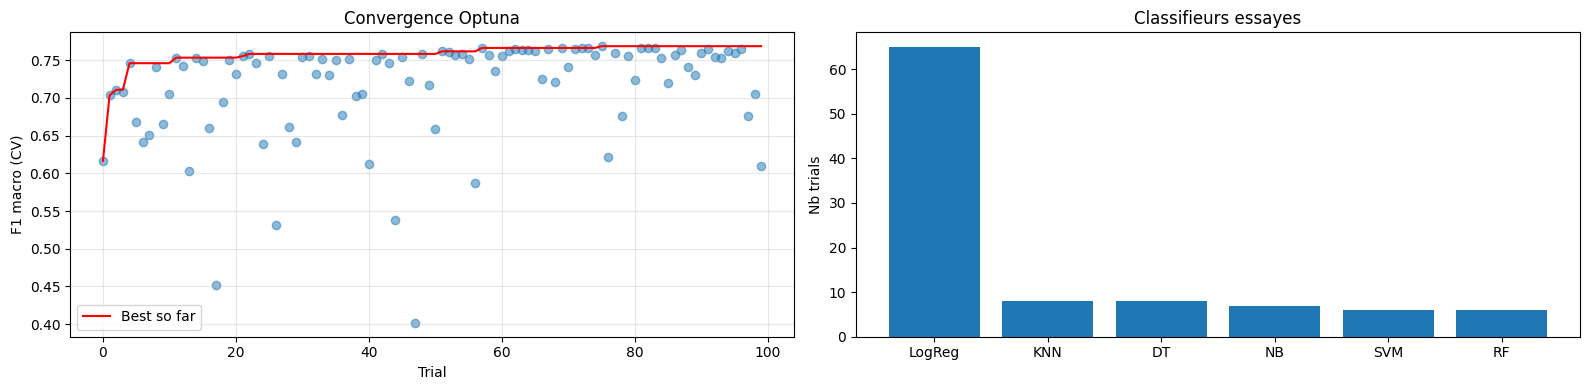

/tmp/ipykernel_11406/306750553.py:22: ExperimentalWarning:

optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.



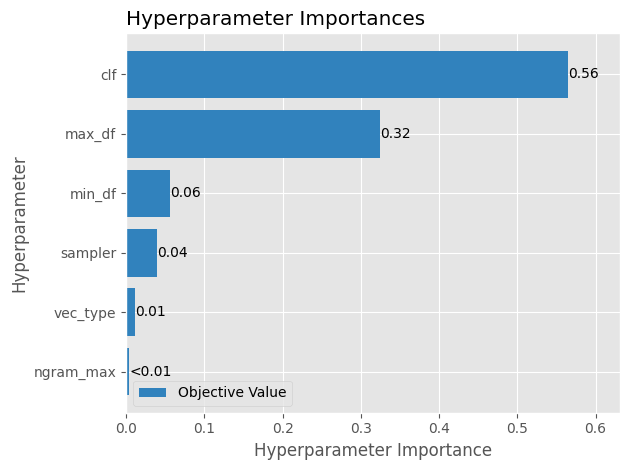

In [14]:
import matplotlib.pyplot as plt
from optuna.visualization.matplotlib import plot_param_importances

# Graphe 1 + 2
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

vals = [t.value for t in study.trials if t.value is not None]
best_so_far = np.maximum.accumulate(vals)
axes[0].scatter(range(len(vals)), vals, alpha=0.5)
axes[0].plot(best_so_far, color="red", label="Best so far")
axes[0].set_title("Convergence Optuna")
axes[0].set_xlabel("Trial"); axes[0].set_ylabel("F1 macro (CV)")
axes[0].legend(); axes[0].grid(alpha=0.3)

clfs = [t.params["clf"] for t in study.trials if "clf" in t.params]
counts = pd.Series(clfs).value_counts()
axes[1].bar(counts.index, counts.values)
axes[1].set_title("Classifieurs essayes"); axes[1].set_ylabel("Nb trials")
plt.tight_layout(); plt.show()

# Graphe 3
plot_param_importances(study)
plt.title("")
plt.tight_layout(); plt.show()

In [15]:
comparaison = pd.DataFrame({
    f"Baseline CV ({best_name})":              {"f1_macro": df_results.loc[best_name, "f1_macro"]},
    f"Optuna CV ({study.best_params['clf']})": {"f1_macro": study.best_value},
}).T
print("=== Comparaison CV " + str(N_FOLDS) + "-folds ===")
print(comparaison.round(3))
print(f"Ecart : {study.best_value - df_results.loc[best_name, 'f1_macro']:+.3f}")

=== Comparaison CV 5-folds ===
                           f1_macro
Baseline CV (Naive Bayes)     0.786
Optuna CV (LogReg)            0.769
Ecart : -0.017


# CLAIM, REF vs CONTEXT

## Manuel

In [16]:
print(df.columns.tolist())

['Unnamed: 0', 'tweet_id', 'text', 'science_related', 'scientific_claim', 'scientific_reference', 'scientific_context', 'text_expanded', 'text_nonalpha']


In [17]:
df_sci = df[df["science_related"] == 1].copy()

m_claim_ref = (df_sci["scientific_claim"] == 1) | (df_sci["scientific_reference"] == 1)
m_context   =  df_sci["scientific_context"] == 1
df_t2 = df_sci[m_claim_ref | m_context].copy()
df_t2["y"] = m_claim_ref[df_t2.index].astype(int)

print("Repartition T2 :")
print(pd.Series(df_t2["y"].values).value_counts().rename({0: "CONTEXT", 1: "CLAIM+REF"}))
print(f"Total : {len(df_t2)} tweets")


Repartition T2 :
CLAIM+REF    124
CONTEXT       33
Name: count, dtype: int64
Total : 157 tweets


In [18]:
from sklearn.model_selection import cross_validate

y_t2 = df_t2["y"].values
results_baseline_t2 = {}

for name, clf in models.items():
    vec = TfidfVectorizer(norm="l2", sublinear_tf=True,
                          min_df=2, max_df=0.8,
                          max_features=5000, ngram_range=(1, 2))
    pipe = Pipeline([
        ("vec",     vec),
        ("sampler", RandomOverSampler(random_state=42)),
        ("clf",     clf),
    ])
    scores = cross_validate(
        pipe, df_t2["text"].values, y_t2, cv=N_FOLDS,
        scoring=["accuracy", "f1_macro", "precision_macro", "recall_macro"],
        n_jobs=-1
    )
    results_baseline_t2[name] = {
        "accuracy":  scores["test_accuracy"].mean(),
        "f1_macro":  scores["test_f1_macro"].mean(),
        "precision": scores["test_precision_macro"].mean(),
        "recall":    scores["test_recall_macro"].mean(),
    }

df_results_t2 = pd.DataFrame(results_baseline_t2).T.sort_values("f1_macro", ascending=False)
print("=== T2 Baseline CV ===")
print(df_results_t2.round(3).to_string())
best_name_t2 = df_results_t2.index[0]
print(f"\nMeilleur : {best_name_t2} (F1-macro = {df_results_t2.loc[best_name_t2, 'f1_macro']:.3f})")


=== T2 Baseline CV ===
               accuracy  f1_macro  precision  recall
SVM               0.924     0.862      0.946   0.827
Naive Bayes       0.808     0.776      0.770   0.866
Random Forest     0.854     0.725      0.741   0.736
KNN               0.732     0.686      0.689   0.762
Decision Tree     0.731     0.621      0.646   0.645

Meilleur : SVM (F1-macro = 0.862)


## Optuna

In [19]:
def objective_t2(trial):
    vec_type  = trial.suggest_categorical("vec_type", ["count", "tfidf"])
    min_df    = trial.suggest_int("min_df", 1, 5)
    max_df    = trial.suggest_float("max_df", 0.5, 1.0)
    ngram_max = trial.suggest_int("ngram_max", 1, 2)
    Vec = CountVectorizer if vec_type == "count" else TfidfVectorizer
    vec = Vec(min_df=min_df, max_df=max_df, ngram_range=(1, ngram_max))

    samp = trial.suggest_categorical("sampler", ["over", "under", "none"])
    sampler = {"over": RandomOverSampler(random_state=42),
               "under": RandomUnderSampler(random_state=42),
               "none": None}[samp]

    steps = [("vec", vec)]
    if sampler is not None:
        steps.append(("sampler", sampler))
    steps.append(("clf", build_clf(trial)))
    pipe = Pipeline(steps)

    return cross_val_score(pipe, df_t2["text"].values, y_t2,
                           cv=N_FOLDS, scoring="f1_macro", n_jobs=-1).mean()

study_t2 = optuna.create_study(direction="maximize",
                               sampler=optuna.samplers.TPESampler(seed=42))
study_t2.optimize(objective_t2, n_trials=100, show_progress_bar=True)

print("Best F1 macro (CV) :", round(study_t2.best_value, 4))
print("Best params :", study_t2.best_params)

  0%|          | 0/100 [00:00<?, ?it/s]

Best F1 macro (CV) : 0.8694
Best params : {'vec_type': 'tfidf', 'min_df': 3, 'max_df': 0.9782571371651377, 'ngram_max': 1, 'sampler': 'none', 'clf': 'KNN', 'knn_k': 7}


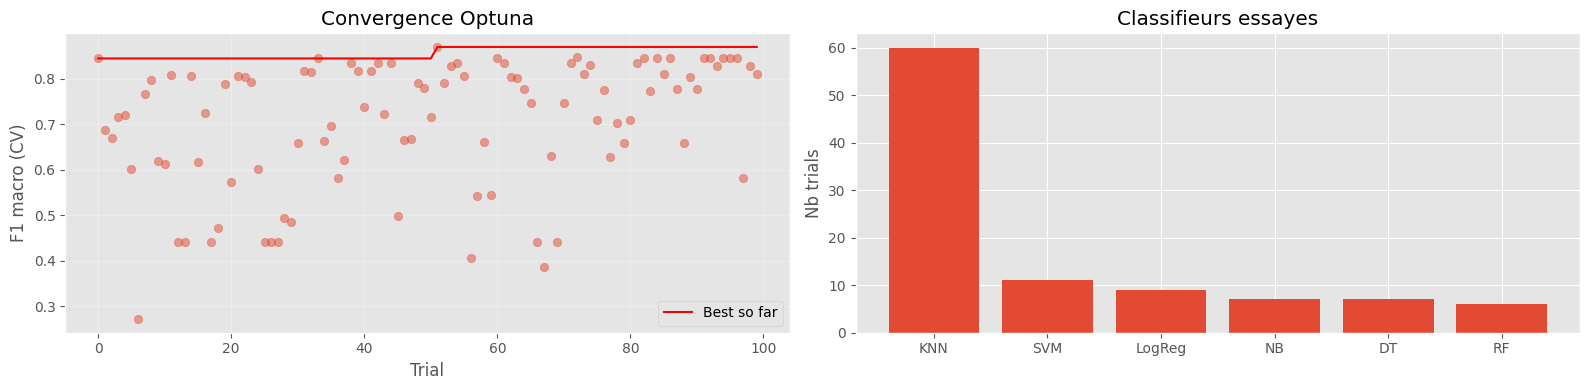

/tmp/ipykernel_11406/2924578543.py:21: ExperimentalWarning:

optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.



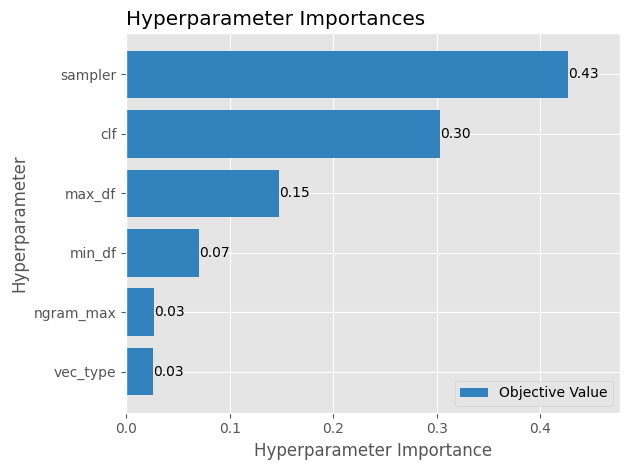

In [20]:
from optuna.visualization.matplotlib import plot_param_importances

# Graphe 1 + 2 : convergence + classifieurs essayes
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

vals = [t.value for t in study_t2.trials if t.value is not None]
best_so_far = np.maximum.accumulate(vals)
axes[0].scatter(range(len(vals)), vals, alpha=0.5)
axes[0].plot(best_so_far, color="red", label="Best so far")
axes[0].set_title("Convergence Optuna")
axes[0].set_xlabel("Trial"); axes[0].set_ylabel("F1 macro (CV)")
axes[0].legend(); axes[0].grid(alpha=0.3)

clfs = [t.params["clf"] for t in study_t2.trials if "clf" in t.params]
counts = pd.Series(clfs).value_counts()
axes[1].bar(counts.index, counts.values)
axes[1].set_title("Classifieurs essayes"); axes[1].set_ylabel("Nb trials")
plt.tight_layout(); plt.show()

# Graphe 3 : importance des hyperparametres
plot_param_importances(study_t2)
plt.title("")
plt.tight_layout(); plt.show()

In [21]:
comparaison_t2 = pd.DataFrame({
    f"Baseline CV ({best_name_t2})":              {"f1_macro": df_results_t2.loc[best_name_t2, "f1_macro"]},
    f"Optuna CV ({study_t2.best_params['clf']})": {"f1_macro": study_t2.best_value},
}).T
print("=== Comparaison T2 ===")
print(comparaison_t2.round(3))
print(f"Ecart : {study_t2.best_value - df_results_t2.loc[best_name_t2, 'f1_macro']:+.3f}")

=== Comparaison T2 ===
                   f1_macro
Baseline CV (SVM)     0.862
Optuna CV (KNN)       0.869
Ecart : +0.008


# CLAIM VS REF VS CONTEXT

## Manuel

In [22]:
df_sci = df[df["science_related"] == 1].copy()
df_t3 = df_sci.copy()

# Matrice cible Y de forme (n, 3) : une colonne binaire par label
LABELS_T3 = ["CLAIM", "REF", "CONTEXT"]
Y_t3 = df_t3[["scientific_claim", "scientific_reference",
              "scientific_context"]].fillna(0).astype(int).values

vectorizer_t3 = TfidfVectorizer(norm="l2", sublinear_tf=True,
                                min_df=2, max_df=0.8,
                                max_features=5000, ngram_range=(1, 2))
X_t3 = vectorizer_t3.fit_transform(df_t3["text"])

# Affichage des combinaisons réellement présentes
combos = pd.Series(["+".join(l for l, v in zip(LABELS_T3, row) if v) or "NONE"
                    for row in Y_t3])
print("Répartition T3 multi-label :")
print(combos.value_counts())
print(f"\nTotal : {len(Y_t3)} tweets")
print(f"Positifs par label {LABELS_T3} : {Y_t3.sum(axis=0)}")

Répartition T3 multi-label :
CLAIM                124
CLAIM+REF+CONTEXT    124
REF+CONTEXT           79
CONTEXT               33
CLAIM+CONTEXT         15
Name: count, dtype: int64

Total : 375 tweets
Positifs par label ['CLAIM', 'REF', 'CONTEXT'] : [263 203 251]


In [23]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import hamming_loss

models_ml = {
    "Decision Tree": OneVsRestClassifier(DecisionTreeClassifier(random_state=42)),
    "Naive Bayes":   OneVsRestClassifier(MultinomialNB()),
    "SVM":           OneVsRestClassifier(LinearSVC(random_state=42, max_iter=2000)),
    "Random Forest": OneVsRestClassifier(RandomForestClassifier(n_estimators=100,
                                                                random_state=42, n_jobs=-1)),
    "KNN":           OneVsRestClassifier(KNeighborsClassifier(n_neighbors=5)),
    "LogReg":        OneVsRestClassifier(LogisticRegression(max_iter=2000, random_state=42)),
}

results_baseline_t3 = {}
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

for name, clf in models_ml.items():
    f1m, hl, subset_acc, acc_avg = [], [], [], []
    for tr, te in kf.split(X_t3):
        clf.fit(X_t3[tr], Y_t3[tr])
        Yp = clf.predict(X_t3[te])
        f1m.append(f1_score(Y_t3[te], Yp, average="macro", zero_division=0))
        hl.append(hamming_loss(Y_t3[te], Yp))
        subset_acc.append(accuracy_score(Y_t3[te], Yp))
        acc_avg.append(np.mean([accuracy_score(Y_t3[te][:, j], Yp[:, j])
                                for j in range(Y_t3.shape[1])]))
    results_baseline_t3[name] = {
        "accuracy":        np.mean(acc_avg),
        "f1_macro":        np.mean(f1m),
        "hamming_loss":    np.mean(hl),
        "subset_accuracy": np.mean(subset_acc),
    }

df_results_t3 = pd.DataFrame(results_baseline_t3).T.sort_values("f1_macro", ascending=False)
print("=== T3 Multi-label Baseline CV ===")
print(df_results_t3.round(3).to_string())
best_name_t3 = df_results_t3.index[0]
print(f"\nMeilleur : {best_name_t3} (F1-macro = {df_results_t3.loc[best_name_t3, 'f1_macro']:.3f})")


=== T3 Multi-label Baseline CV ===
               accuracy  f1_macro  hamming_loss  subset_accuracy
Random Forest     0.747     0.810         0.253            0.493
LogReg            0.760     0.804         0.240            0.507
SVM               0.755     0.802         0.245            0.488
Naive Bayes       0.688     0.789         0.312            0.339
KNN               0.667     0.754         0.333            0.397
Decision Tree     0.680     0.740         0.320            0.363

Meilleur : Random Forest (F1-macro = 0.810)


## Optuna

In [24]:
def build_clf_ml(trial):
    name = trial.suggest_categorical("clf", ["SVM", "LogReg", "NB", "KNN", "RF", "DT"])
    if name == "SVM":
        base = LinearSVC(C=trial.suggest_float("svm_C", 1e-3, 10, log=True),
                         random_state=42, max_iter=3000)
    elif name == "LogReg":
        base = LogisticRegression(C=trial.suggest_float("lr_C", 1e-3, 10, log=True),
                                  random_state=42, max_iter=2000)
    elif name == "NB":
        base = MultinomialNB(alpha=trial.suggest_float("nb_alpha", 1e-3, 10, log=True))
    elif name == "KNN":
        base = KNeighborsClassifier(n_neighbors=trial.suggest_int("knn_k", 3, 15))
    elif name == "RF":
        base = RandomForestClassifier(
            n_estimators=trial.suggest_int("rf_n", 50, 300),
            max_depth=trial.suggest_int("rf_d", 5, 50),
            random_state=42, n_jobs=-1)
    else:
        base = DecisionTreeClassifier(max_depth=trial.suggest_int("dt_d", 5, 50),
                                      random_state=42)
    return OneVsRestClassifier(base)


def objective_t3_ml(trial):
    vec_type  = trial.suggest_categorical("vec_type", ["count", "tfidf"])
    min_df    = trial.suggest_int("min_df", 1, 5)
    max_df    = trial.suggest_float("max_df", 0.5, 1.0)
    ngram_max = trial.suggest_int("ngram_max", 1, 2)
    Vec = CountVectorizer if vec_type == "count" else TfidfVectorizer

    samp = trial.suggest_categorical("sampler", ["over", "under", "none"])

    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    scores = []
    texts = df_t3["text"].values
    for tr, te in kf.split(texts):
        vec = Vec(min_df=min_df, max_df=max_df, ngram_range=(1, ngram_max))
        Xtr = vec.fit_transform(texts[tr])
        Xte = vec.transform(texts[te])

        if samp == "over":
            Xtr_res, Y_res = RandomOverSampler(random_state=42).fit_resample(Xtr, Y_t3[tr])
        elif samp == "under":
            Xtr_res, Y_res = RandomUnderSampler(random_state=42).fit_resample(Xtr, Y_t3[tr])
        else:
            Xtr_res, Y_res = Xtr, Y_t3[tr]

        clf = build_clf_ml(trial)
        clf.fit(Xtr_res, Y_res)
        scores.append(f1_score(Y_t3[te], clf.predict(Xte), average="macro", zero_division=0))
    return float(np.mean(scores))


study_t3 = optuna.create_study(direction="maximize",
                               sampler=optuna.samplers.TPESampler(seed=42))
study_t3.optimize(objective_t3_ml, n_trials=100, show_progress_bar=True)

print("Best F1-macro (CV) :", round(study_t3.best_value, 4))
print("Best params :", study_t3.best_params)


  0%|          | 0/100 [00:00<?, ?it/s]

Best F1-macro (CV) : 0.8314
Best params : {'vec_type': 'count', 'min_df': 1, 'max_df': 0.8947566428411926, 'ngram_max': 1, 'clf': 'RF', 'rf_n': 186, 'rf_d': 48}


=== Comparaison T3 ===
                             f1_macro
Baseline CV (Random Forest)     0.810
Optuna CV (RF)                  0.831
Ecart : +0.021



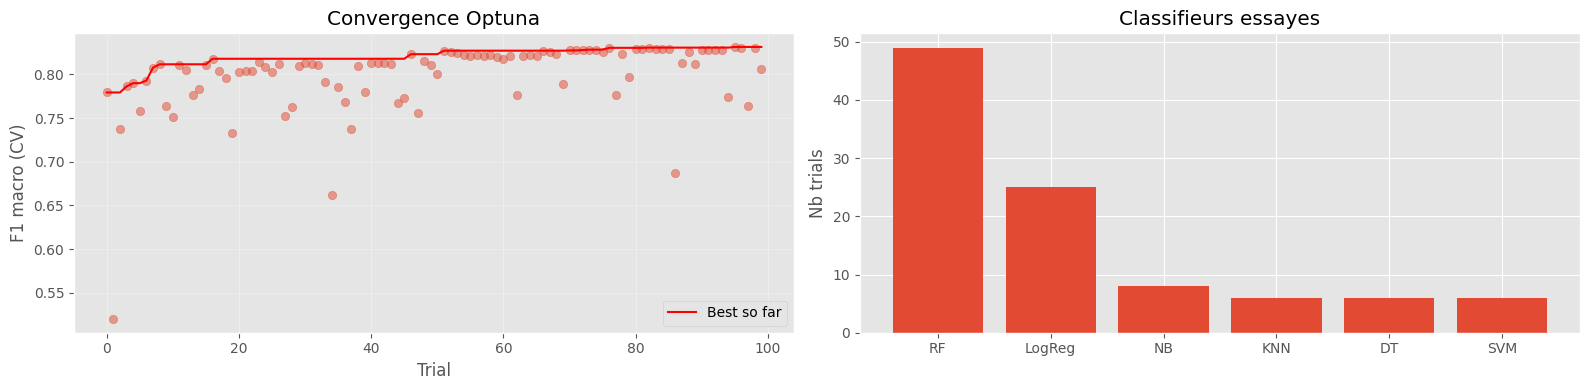

/tmp/ipykernel_11406/1953080272.py:25: ExperimentalWarning:

optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.



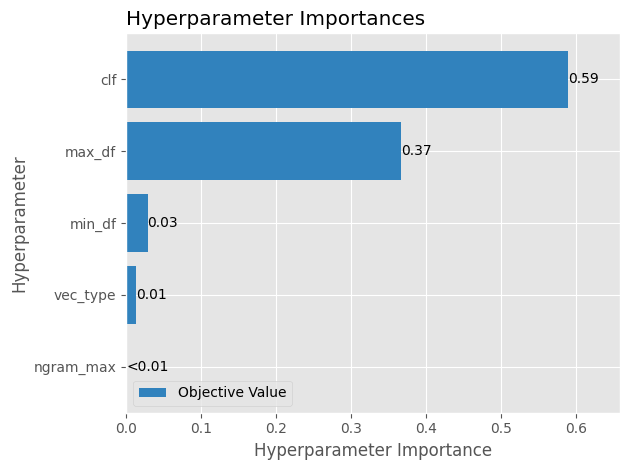

In [25]:
comparaison_t3 = pd.DataFrame({
    f"Baseline CV ({best_name_t3})":              {"f1_macro": df_results_t3.loc[best_name_t3, "f1_macro"]},
    f"Optuna CV ({study_t3.best_params['clf']})": {"f1_macro": study_t3.best_value},
}).T
print("=== Comparaison T3 ===")
print(comparaison_t3.round(3))
print(f"Ecart : {study_t3.best_value - df_results_t3.loc[best_name_t3, 'f1_macro']:+.3f}\n")

# Graphes
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
vals = [t.value for t in study_t3.trials if t.value is not None]
best_so_far = np.maximum.accumulate(vals)
axes[0].scatter(range(len(vals)), vals, alpha=0.5)
axes[0].plot(best_so_far, color="red", label="Best so far")
axes[0].set_title("Convergence Optuna")
axes[0].set_xlabel("Trial"); axes[0].set_ylabel("F1 macro (CV)")
axes[0].legend(); axes[0].grid(alpha=0.3)

clfs = [t.params["clf"] for t in study_t3.trials if "clf" in t.params]
counts = pd.Series(clfs).value_counts()
axes[1].bar(counts.index, counts.values)
axes[1].set_title("Classifieurs essayes"); axes[1].set_ylabel("Nb trials")
plt.tight_layout(); plt.show()

plot_param_importances(study_t3)
plt.title("")
plt.tight_layout(); plt.show()

In [26]:
print(f"Best params Optuna T3 : {study_t3.best_params}")


=== Comparaison T3 ===
                             f1_macro
Baseline CV (Random Forest)     0.810
Optuna CV (RF)                  0.831
Ecart : +0.021

Best params Optuna T3 : {'vec_type': 'count', 'min_df': 1, 'max_df': 0.8947566428411926, 'ngram_max': 1, 'clf': 'RF', 'rf_n': 186, 'rf_d': 48}


# Comparaisons

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


def _build_pipe_optuna(study):
    """Reconstruit le pipeline avec les meilleurs hyperparamètres Optuna."""
    bp = study.best_params
    Vec = CountVectorizer if bp["vec_type"] == "count" else TfidfVectorizer
    vec = Vec(min_df=bp["min_df"], max_df=bp["max_df"], ngram_range=(1, bp["ngram_max"]))

    sampler = {"over":  RandomOverSampler(random_state=42),
               "under": RandomUnderSampler(random_state=42),
               "none":  None}[bp["sampler"]]

    clf_name = bp["clf"]
    if   clf_name == "SVM":    clf = LinearSVC(C=bp["svm_C"], random_state=42, max_iter=3000)
    elif clf_name == "LogReg": clf = LogisticRegression(C=bp["lr_C"], random_state=42, max_iter=2000)
    elif clf_name == "NB":     clf = MultinomialNB(alpha=bp["nb_alpha"])
    elif clf_name == "KNN":    clf = KNeighborsClassifier(n_neighbors=bp["knn_k"])
    elif clf_name == "RF":     clf = RandomForestClassifier(n_estimators=bp["rf_n"],
                                                             max_depth=bp["rf_d"],
                                                             random_state=42, n_jobs=-1)
    else:                      clf = DecisionTreeClassifier(max_depth=bp["dt_d"], random_state=42)

    steps = [("vec", vec)]
    if sampler is not None:
        steps.append(("sampler", sampler))
    steps.append(("clf", clf))
    return Pipeline(steps), clf_name


def matrice_confusion_optuna(study, X_train, y_train, X_test, y_test, labels, titre):
    """
    Entraîne le pipeline (meilleurs params Optuna) sur X_train/y_train
    et évalue sur X_test/y_test — held-out set, jamais vu à l'entraînement.
    """
    pipe, clf_name = _build_pipe_optuna(study)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap="Blues")
    plt.title(f"{titre} Optuna — {clf_name} (test set, n={len(y_test)})")
    plt.show()


def matrice_confusion_baseline(model_name, X_train, y_train, X_test, y_test, labels, titre):
    """
    Entraîne le pipeline baseline sur X_train/y_train
    et évalue sur X_test/y_test.
    """
    pipe = Pipeline([
        ("sampler", RandomOverSampler(random_state=42)),
        ("clf",     models[model_name]),
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap="Oranges")
    plt.title(f"{titre} Baseline — {model_name} (test set, n={len(y_test)})")
    plt.show()


In [ ]:
# ── Splits train/test 80/20 pour les matrices de confusion ──────────────────
# T1 : déjà défini en Cell 21 → X_tr / X_te / y_tr / y_te (texte brut)

# T2 : on repart du texte brut — le vectoriseur sera fitté uniquement sur le train
X_text_t2 = df_t2["text"].values
X_tr_t2, X_te_t2, y_tr_t2, y_te_t2 = train_test_split(
    X_text_t2, y_t2, test_size=0.2, random_state=42, stratify=y_t2
)

# T3 : idem, texte brut
X_text_t3 = df_t3["text"].values
X_tr_t3, X_te_t3, Y_tr_t3, Y_te_t3 = train_test_split(
    X_text_t3, Y_t3, test_size=0.2, random_state=42
)

print(f"T1 — train: {len(X_tr)}, test: {len(X_te)}")
print(f"T2 — train: {len(X_tr_t2)}, test: {len(X_te_t2)}")
print(f"T3 — train: {len(X_tr_t3)}, test: {len(X_te_t3)}")


# ── Matrices de confusion T1 ──────────────────────────────────────────────────
matrice_confusion_optuna(
    study,
    X_tr, y_tr, X_te, y_te,
    ["NON-SCI", "SCI"], "T1"
)

matrice_confusion_baseline(
    best_name,
    X_tr, y_tr, X_te, y_te,
    ["NON-SCI", "SCI"], "T1"
)


In [ ]:
# ── Matrices de confusion T2 ──────────────────────────────────────────────────
matrice_confusion_optuna(
    study_t2,
    X_tr_t2, y_tr_t2, X_te_t2, y_te_t2,
    ["CONTEXT", "CLAIM+REF"], "T2"
)

matrice_confusion_baseline(
    best_name_t2,
    X_tr_t2, y_tr_t2, X_te_t2, y_te_t2,
    ["CONTEXT", "CLAIM+REF"], "T2"
)


=== T3 — Classification report ===
              precision    recall  f1-score   support

       CLAIM       0.75      0.98      0.85       263
         REF       0.66      0.98      0.79       203
     CONTEXT       0.78      0.96      0.86       251

   micro avg       0.73      0.97      0.83       717
   macro avg       0.73      0.97      0.83       717
weighted avg       0.74      0.97      0.84       717
 samples avg       0.76      0.97      0.82       717

Hamming loss            : 0.245
Subset accuracy (exact) : 0.509


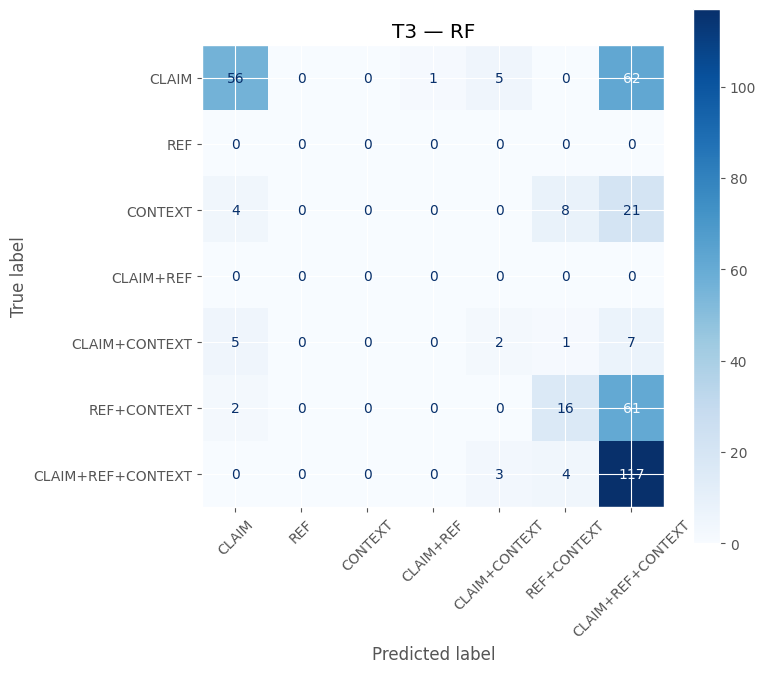

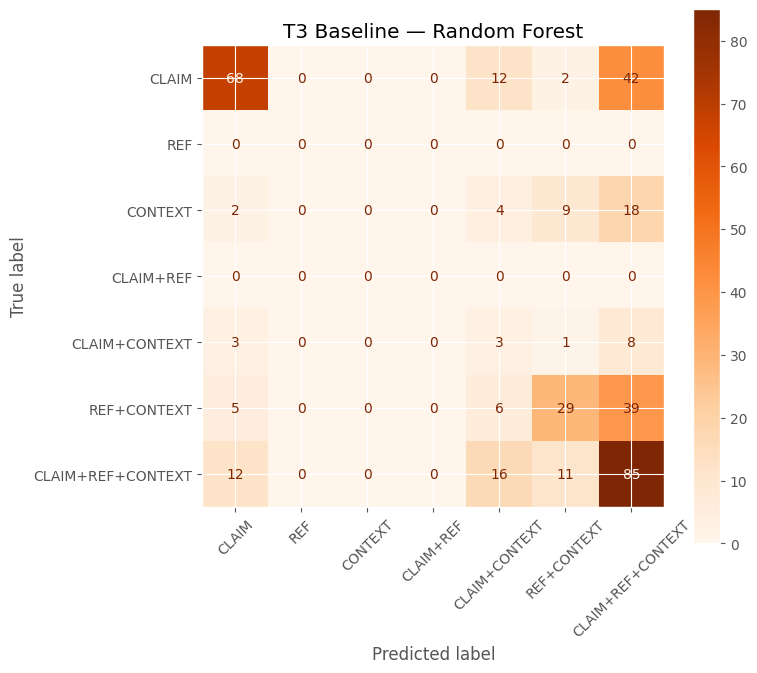

In [30]:
from sklearn.metrics import (ConfusionMatrixDisplay, confusion_matrix,
                             classification_report)
ALL_COMBOS = ["CLAIM", "REF", "CONTEXT",
              "CLAIM+REF", "CLAIM+CONTEXT", "REF+CONTEXT",
              "CLAIM+REF+CONTEXT"]

def _combos(Y, labels):
    return np.array(["+".join(l for l, v in zip(labels, row) if v) or "NONE"
                     for row in Y])


def matrice_confusion_optuna_ml(study, X_text, Y, labels, titre):
    bp = study.best_params
    Vec = CountVectorizer if bp["vec_type"] == "count" else TfidfVectorizer

    def make_clf():
        n = bp["clf"]
        if n == "SVM":      base = LinearSVC(C=bp["svm_C"], random_state=42, max_iter=3000)
        elif n == "LogReg": base = LogisticRegression(C=bp["lr_C"], random_state=42, max_iter=2000)
        elif n == "NB":     base = MultinomialNB(alpha=bp["nb_alpha"])
        elif n == "KNN":    base = KNeighborsClassifier(n_neighbors=bp["knn_k"])
        elif n == "RF":     base = RandomForestClassifier(n_estimators=bp["rf_n"], max_depth=bp["rf_d"],
                                                          random_state=42, n_jobs=-1)
        else:               base = DecisionTreeClassifier(max_depth=bp["dt_d"], random_state=42)
        return OneVsRestClassifier(base)

    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    Y_pred = np.zeros_like(Y)
    for tr, te in kf.split(X_text):
        vec = Vec(min_df=bp["min_df"], max_df=bp["max_df"], ngram_range=(1, bp["ngram_max"]))
        Xtr = vec.fit_transform(X_text[tr]); Xte = vec.transform(X_text[te])
        clf = make_clf(); clf.fit(Xtr, Y[tr])
        Y_pred[te] = clf.predict(Xte)

    print(f"=== {titre} — Classification report ===")
    print(classification_report(Y, Y_pred, target_names=labels, zero_division=0))
    print(f"Hamming loss            : {hamming_loss(Y, Y_pred):.3f}")
    print(f"Subset accuracy (exact) : {accuracy_score(Y, Y_pred):.3f}")

    ct, cp = _combos(Y, labels), _combos(Y_pred, labels)
    cm = confusion_matrix(ct, cp, labels=ALL_COMBOS)
    fig, ax = plt.subplots(figsize=(8, 7))
    ConfusionMatrixDisplay(cm, display_labels=ALL_COMBOS).plot(
        ax=ax, cmap="Blues", xticks_rotation=45)   # ou "Oranges" pour baseline
    ax.set_title(f"{titre} — {bp['clf']}")           # ou f"{titre} Baseline — {model_name}"
    plt.tight_layout(); plt.show()


def matrice_confusion_baseline_ml(model_name, X, Y, labels, titre):
    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    Y_pred = np.zeros_like(Y)
    for tr, te in kf.split(X):
        clf = models_ml[model_name]
        clf.fit(X[tr], Y[tr])
        Y_pred[te] = clf.predict(X[te])

    ct, cp = _combos(Y, labels), _combos(Y_pred, labels)
    uniq = sorted(set(ct) | set(cp))
    cm = confusion_matrix(ct, cp, labels=ALL_COMBOS)
    fig, ax = plt.subplots(figsize=(8, 7))
    ConfusionMatrixDisplay(cm, display_labels=ALL_COMBOS).plot(ax=ax, cmap="Oranges", xticks_rotation=45)
    ax.set_title(f"{titre} Baseline — {model_name}")
    plt.tight_layout(); plt.show()


matrice_confusion_optuna_ml(study_t3, df_t3["text"].values, Y_t3, LABELS_T3, "T3")
matrice_confusion_baseline_ml(best_name_t3, X_t3, Y_t3, LABELS_T3, "T3")

In [34]:
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import RandomOverSampler
from sklearn.multiclass import OneVsRestClassifier

def top_features(X_text, y, class_labels, titre, top_n=15):
    vec = TfidfVectorizer(min_df=2, max_df=0.8, ngram_range=(1, 2),
                          sublinear_tf=True)
    X_vec = vec.fit_transform(X_text)
    feature_names = vec.get_feature_names_out()

    print(f"\n=== {titre} — Top {top_n} features par classe ===")

    if y.ndim == 1:
        ros = RandomOverSampler(random_state=42)
        X_res, y_res = ros.fit_resample(X_vec, y)

        clf = LogisticRegression(max_iter=2000, random_state=42)
        clf.fit(X_res, y_res)

        if len(class_labels) == 2:
            coefs = clf.coef_[0]
            top_pos = np.argsort(coefs)[-top_n:][::-1]
            top_neg = np.argsort(coefs)[:top_n]
            print(f"\nVers {class_labels[1]} :")
            for i in top_pos:
                print(f"  {feature_names[i]:30s}  {coefs[i]:+.3f}")
            print(f"\nVers {class_labels[0]} :")
            for i in top_neg:
                print(f"  {feature_names[i]:30s}  {coefs[i]:+.3f}")
        else:
            for k, label in enumerate(class_labels):
                top = np.argsort(clf.coef_[k])[-top_n:][::-1]
                print(f"\nClasse {label} :")
                for i in top:
                    print(f"  {feature_names[i]:30s}  {clf.coef_[k, i]:+.3f}")
    else:
        base_clf = LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced')
        clf = OneVsRestClassifier(base_clf)
        clf.fit(X_vec, y)

        for k, label in enumerate(class_labels):
            top = np.argsort(clf.estimators_[k].coef_[0])[-top_n:][::-1]
            print(f"\nClasse {label} :")
            for i in top:
                print(f"  {feature_names[i]:30s}  {clf.estimators_[k].coef_[0, i]:+.3f}")


In [35]:
top_features(df["text"].values,    df["science_related"].values,
             ["NON-SCI", "SCI"], "T1", top_n=15)

top_features(df_t2["text"].values, y_t2,
             ["CONTEXT", "CLAIM+REF"], "T2", top_n=15)

top_features(df_t3["text"].values, Y_t3,
             ["CLAIM", "REF", "CONTEXT"], "T3", top_n=15)


=== T1 — Top 15 features par classe ===

Vers SCI :
  of                              +2.383
  research                        +2.076
  study                           +2.066
  health                          +1.919
  cancer                          +1.738
  eurekamag                       +1.658
  https                           +1.605
  https co                        +1.605
  co                              +1.597
  can                             +1.556
  men                             +1.411
  in                              +1.372
  risk                            +1.247
  climate                         +1.238
  non                             +1.128

Vers NON-SCI :
  stop                            -4.045
  support                         -3.301
  reports                         -2.664
  to stop                         -1.228
  please                          -1.106
  need                            -1.087
  promote                         -1.041
  treat                      